# Chronos-Bolt layer probing

## Setup

In [236]:
import torch, sys
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from chronos import BaseChronosPipeline
import pandas as pd
import json
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import tqdm
from sklearn.decomposition import PCA

sys.path.insert(0, "../data/synthetic/")         
import signalGenerator as sg   
from pandas import json_normalize

In [237]:
# set seeds for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
rngm = np.random.default_rng(SEED)

In [238]:
pipeline = BaseChronosPipeline.from_pretrained("amazon/chronos-bolt-tiny", device_map="cpu")
model = pipeline.model
cfg = model.config.chronos_config
print(json.dumps(cfg, indent=4))

DEFAULT_PATCH_SIZE = cfg["input_patch_size"]
DEFAULT_STRIDE = cfg["input_patch_stride"]
PRED_LEN_DEFAULT = cfg["prediction_length"]
N_ENC = len(model.encoder.block)
N_DEC = len(model.decoder.block)
QUANTILES = cfg["quantiles"]

{
    "context_length": 2048,
    "input_patch_size": 16,
    "input_patch_stride": 16,
    "prediction_length": 64,
    "quantiles": [
        0.1,
        0.2,
        0.3,
        0.4,
        0.5,
        0.6,
        0.7,
        0.8,
        0.9
    ],
    "use_reg_token": true
}


In [ ]:
CONTEXT_LEN = 512
# We are using 512 as well as the paper, but we can experiment with different context lengths to see how it affects the results. 
pipeline.model.config.chronos_config["context_length"] = CONTEXT_LEN
cfg = pipeline.model.config.chronos_config
CONTEXT_LEN = cfg["context_length"]

In [240]:
OUT = Path("../outputs/signals/")
existing = [d for d in OUT.iterdir() if d.is_dir() and d.name.startswith("signal_")]
if existing:
    i = max([int(d.name.split("_")[1]) for d in existing]) + 1
else:    
    i = 0
OUT = OUT/f"signal_{i}"
OUT.mkdir(parents=True, exist_ok=True)
print(f"Saving outputs to {OUT}")

Saving outputs to ..\outputs\signals\signal_26


## 1 - Generate the probe signal here (named & saved)
Edit `GEN` and `INJECT`. cpp = cycles per patch (blind spots at integer cpp); or use mode `"hz"`
(cpp = value*P/fs). The signal is saved under `../outputs/signals/<name>.npy`.

Rebember that we work on cpp to inject and evaluate the signal (or the frequency in Hz)
The critical condition is that S/T0 or/and P/T0 are integers, where T0 is the period of the signal. 
In this case, the signal is aliased and not captured by the model.

To reach that condition cpp = P/T0 = P*f/fs = value, where value is an integer. 
So, for example, with P=16 and fs=256, cpp=4 means f=64Hz, which is critical.
So, for example, with P=16 and fs=256, cpp=5 means f=80Hz, which is not critical.

In [ ]:
json_config = [
    {
        "generator": "kernelsynth",
        "n_realizations": 5,
        "seed": 15,
        "params": {
            "J": 5,
            "l_syn": 512,
            "fs": 256,
            "jitter": 0.0001,
            "P": 16,
            "inject": {
                "mode": "cpp",
                "value": 4.0,
                "amplitude": 0.01,
                "phase": 0.0
            }
        }
    }
]

In [242]:
# json_config = [
#     {
#         "generator": "tsmixup",
#         "n_realizations": 5,
#         "seed": 13,
#         "params": {
#             "K": 3,
#             "alpha": 1.5,
#             "l_min": CONTEXT_LEN,
#             "l_max": CONTEXT_LEN,
#             "fs": 256,
#             "P": 16,
#             "t_lengths": [
#                 256,
#                 384,
#                 512
#             ],
#             "inject": {
#                 "mode": "hz",
#                 "value": 120,
#                 "amplitude": 0.03,
#                 "phase": 1.5707963
#             }
#         }
#     }
# ]

In [243]:
if json_config[0]["generator"] == "kernelsynth":
    json_config[0]["params"]["l_syn"] = CONTEXT_LEN
    # the signal fed to the model is the first CONTEXT_LEN samples of the generated signal, 
    # which is the default context length of the model, and also the length of the generated signal (l_syn) to avoid having to crop it
    gen = sg.runKernelSynth(json_config[0]["params"], json_config[0]["seed"], output_dir=OUT)
    NAME = "kernelsynth"
else:
    json_config[0]["params"]["l_min"] = CONTEXT_LEN
    json_config[0]["params"]["l_max"] = CONTEXT_LEN
    gen = sg.runTSMixup(json_config[0]["params"], json_config[0]["seed"], output_dir=OUT)
    NAME = "tsmixup"

print(gen.getParameters())

{'generator': 'KernelSynth', 'J': 5, 'l_syn': 256, 'fs': 256, 'jitter': 0.0001, 'inject': {'mode': 'cpp', 'value': 4.0, 'amplitude': 0.01, 'phase': 0.0}}


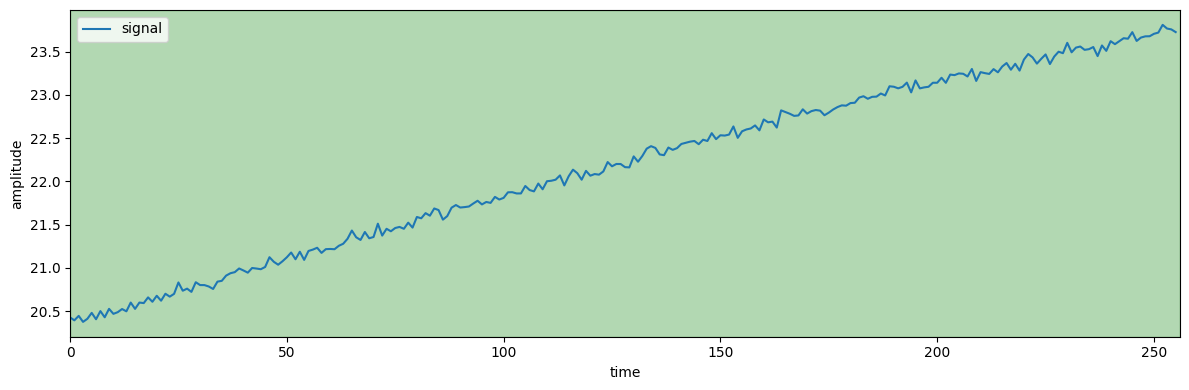

In [244]:
signal = np.asarray(gen.generate(), float).ravel()
gen.save(signal)
with open(OUT/"config.json", "w") as f:
    json.dump(json_config, f, indent=4)
    
plt.figure(figsize=(12, 4))
plt.plot(signal, label="signal")
plt.axvspan(0, CONTEXT_LEN, color="green", alpha=0.3)
plt.xlabel("time")
plt.ylabel("amplitude")
plt.legend();
plt.xlim(0, len(signal));
plt.tight_layout()

plt.savefig(OUT/f"{NAME}.png", dpi=140, bbox_inches="tight") 
plt.show() 

In [245]:
# we need to compute the cpp of the injected component to interpret the results of the probing in terms of aliasing
inject = json_config[0]["params"]["inject"]
INJECT = {
    "mode": inject["mode"],
    "value": inject["value"] if inject["mode"] == "cpp" else inject["value"] * DEFAULT_PATCH_SIZE / 256,
    "amplitude": inject["amplitude"],
    "phase": inject["phase"]
}
FS = json_config[0]["params"]["fs"]

# cpp, cycles per patch, computation
cpp = INJECT["value"] if INJECT["mode"] == "cpp" else INJECT["value"] * DEFAULT_PATCH_SIZE / FS

## 2 - Capture every stage

In [246]:
def cut(signal, stride=DEFAULT_STRIDE): 
    """
    Cuts the input signal into patches of size DEFAULT_PATCH_SIZE with stride stride.
    Returns a matrix of shape (num_patches, DEFAULT_PATCH_SIZE) where num_patches is the number of patches that can be extracted from x with the given DEFAULT_PATCH_SIZE and stride.
    """
    patches = []
    for i in range(0, len(signal)-DEFAULT_PATCH_SIZE+1, stride):
        patch = signal[i:i+DEFAULT_PATCH_SIZE]
        patches.append(patch)
    return np.stack(patches)

In [247]:
def as_matrix(t):
    """
    Converts a tensor or a tuple of tensors to a numpy matrix. If the input is a tuple, it takes the first element.
    If the resulting array has 3 dimensions, it returns the first element along the first dimension, otherwise it returns the array as is.
    """
    if isinstance(t, tuple): t = t[0]
    a = t.detach().cpu().numpy(); return a[0] if a.ndim == 3 else a

In [248]:
def forward_capture(context, stride=DEFAULT_STRIDE):
    """
    Feeds the input context to the model and captures the outputs of each layer in the cap dictionary. 
    The keys of the cap dictionary are the names of the layers and the values are the outputs of the layers as numpy matrices.
    The stride parameter is used to set the patch stride of the model before feeding the input and is reset to the default value after the forward pass.
    """

    # Hooks definition: we define a hook function that captures the output of a layer and stores it in the cap dictionary. We register this hook to each layer we want to capture.
    cap, handles = {}, []
    model.patch.patch_stride = stride

    def save(key, use_in=False):
        def hook(m, i, o): 
            """The hook function that captures the output of the layer. If use_in is True, it captures the input to the layer instead of the output."""
            cap[key] = as_matrix(i[0] if use_in else o)
        return hook
    
    if hasattr(model, "instance_norm"): 
        handles.append(model.instance_norm.register_forward_hook(save("scaled")))
    handles.append(model.patch.register_forward_hook(save("patched")))
    handles.append(model.input_patch_embedding.register_forward_hook(save("pre_embed", True)))
    handles.append(model.input_patch_embedding.register_forward_hook(save("post_embed")))
    for k, b in enumerate(model.encoder.block): 
        handles.append(b.register_forward_hook(save(f"enc{k}")))
    for k, b in enumerate(model.decoder.block): 
        handles.append(b.register_forward_hook(save(f"dec{k}")))
    if hasattr(model, "output_patch_embedding"): 
        handles.append(model.output_patch_embedding.register_forward_hook(save("dec_out", True)))
    
    
    # Forward pass: we feed the input context to the model and get the forecast. The hooks will capture the outputs of the layers during the forward pass and store them in the cap dictionary.
    x = torch.tensor(np.asarray(context, np.float32)).unsqueeze(0)
    with torch.no_grad():
        fc = pipeline.predict(x, prediction_length=PRED_LEN_DEFAULT)
    for h in handles: h.remove()
    model.patch.patch_stride = DEFAULT_STRIDE


    # We need to capture the input patches as well, which are not the output of any layer but are useful for our analysis. 
    # We can compute them by cutting the input context into patches with the same patch size and stride as the model.
    sc = cap.pop("scaled", None)
    cap = {"input":  cut(context, stride=stride),
           "scaled": cut(np.asarray(sc).ravel(), stride=stride) if sc is not None
                     else cut(context, stride=stride),
           **cap}


    # Reset the patch stride to the default value after the forward pass to avoid affecting other operations that might use the model later.
    model.patch.patch_stride = DEFAULT_STRIDE
    return fc, cap

In [249]:
forecast, cap = forward_capture(signal, stride=DEFAULT_STRIDE)
# forecast is the output of the model, which is the predicted future values. 
# cap is a dictionary that contains the outputs of the layers that we captured with the hooks. 
# The keys of the cap dictionary are the names of the layers and the values are the outputs of the layers as numpy matrices.
#  We also include the input and scaled versions of the input in the cap dictionary for comparison.

STAGES = ["input","scaled","patched","pre_embed","post_embed",
          *[f"enc{k}" for k in range(N_ENC)], *[f"dec{k}" for k in range(N_DEC)], "dec_out"] 
# we define the stages we want to analyze in the probing. 
# We include the input, the scaled input, the patched input, the pre and post embedding of the input, the output of each encoder 
# and decoder block, and the output of the decoder before the final projection (if it exists).
STAGES = [s for s in STAGES if s in cap] # we filter the stages to keep only those that were actually captured in the cap dictionary, since some layers might not be present in the model depending on its configuration.
print("captured:", len(STAGES), "stages")
print(STAGES)

captured: 14 stages
['input', 'scaled', 'patched', 'pre_embed', 'post_embed', 'enc0', 'enc1', 'enc2', 'enc3', 'dec0', 'dec1', 'dec2', 'dec3', 'dec_out']


## 3 - Relevance detector

### 3.1 - Sensitivity of representation (SCPA)

**What it measures**: how much the injected component physically perturbs each stage's
representation, using the signal's own background as a matched control.
The background is recovered exactly as `background = signal - tone` (since the generator
builds `signal = normalised_bg + amp·sin(...)`). The metric per stage `s` is:

    relevance_s = || h_s(signal) - h_s(background) || / || h_s(background) ||

High = the tone's footprint is still imprinted at `s`; a drop marks the stage where the
model begins representing `signal` and its background alike, i.e. the component is eaten.

**Why leakage-free**: no labels, no classifier. It is a direct causal contrast —
the same background with vs without the tone — so no prediction target can leak.

**Key limitation**: `stage_dist` captures *any* perturbation, linear or not. It cannot
distinguish between "the tone is linearly readable" and "the tone changes the norm in a
nonlinear, undecodable way." For the linear-accessibility dimension, see Section 3b (MDL).

In [250]:
def stage_dist(a, b):
    """Computes a distance between two matrices a and b. 
    The distance is defined as the mean absolute difference between a and b, normalized by the mean absolute value of b to avoid scale issues. 
    The function first truncates a and b to the same length, converts them to numpy arrays of type float, and then computes the distance. """
    m = min(len(a), len(b)); a, b = np.asarray(a[:m], float), np.asarray(b[:m], float)
    return float(np.abs(a-b).mean() / (np.abs(b).mean() + 1e-9))

In [251]:
# 1. Injected signal recovery

spec = json_config[0]["params"]["inject"] 
# we get the specifications of the injected component from the config to recover the background signal by subtracting the injected tone from the original signal. 
# This is necessary to analyze how the model processes the injected component and how it affects the activations of the layers compared to a matched control where the tone is not present.
amp_ = float(spec.get("amplitude", 1.0)); ph_ = float(spec.get("phase", 0.0))

n = np.arange(len(signal))
if spec["mode"] == "cpp":
    tone = amp_ * np.sin(2*np.pi*float(spec["value"])*n/DEFAULT_PATCH_SIZE + ph_)
else:  # hz
    fs_ = float(json_config[0]["params"].get("fs", 256))
    tone = amp_ * np.sin(2*np.pi*float(spec["value"])*(n/fs_) + ph_)

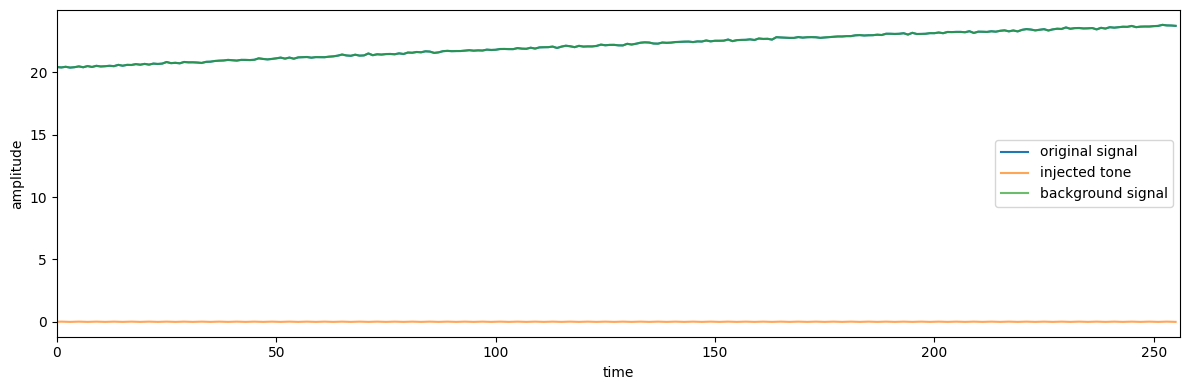

In [252]:
# 2. Background signal recovery

background = signal - tone

fig = plt.figure(figsize=(12, 4))
plt.plot(signal, label="original signal")
plt.plot(tone, label="injected tone", alpha=0.7)
plt.plot(signal-tone, label="background signal", alpha=0.7)

plt.xlabel("time"); plt.ylabel("amplitude"); plt.legend();
plt.xlim(0, len(signal));
plt.tight_layout()
plt.savefig(OUT/"signal_analysis.png", dpi=140, bbox_inches="tight")
plt.show()

In [253]:
_, cap_bg = forward_capture(background[:CONTEXT_LEN]) 
# we feed the background signal to the model and capture the outputs of the layers in the cap_bg dictionary, 
# which we will use as a control to compare with the cap dictionary that contains the activations for the original signal with the injected tone.

# as well as before we filter the stages to keep only those that were actually captured in the cap_bg dictionary, since some layers might not be present in the model depending on its configuration.
REL_STAGES = ['input', 'pre_embed', 'post_embed', *[f"enc{k}" for k in range(N_ENC)], 
              *[f"dec{k}" for k in range(N_DEC)], "dec_out"]
REL_STAGES = [s for s in REL_STAGES if s in cap and s in cap_bg]
rel = [stage_dist(cap[s], cap_bg[s]) for s in REL_STAGES] 
xs = np.arange(len(REL_STAGES)); jmin = int(np.argmin(rel))

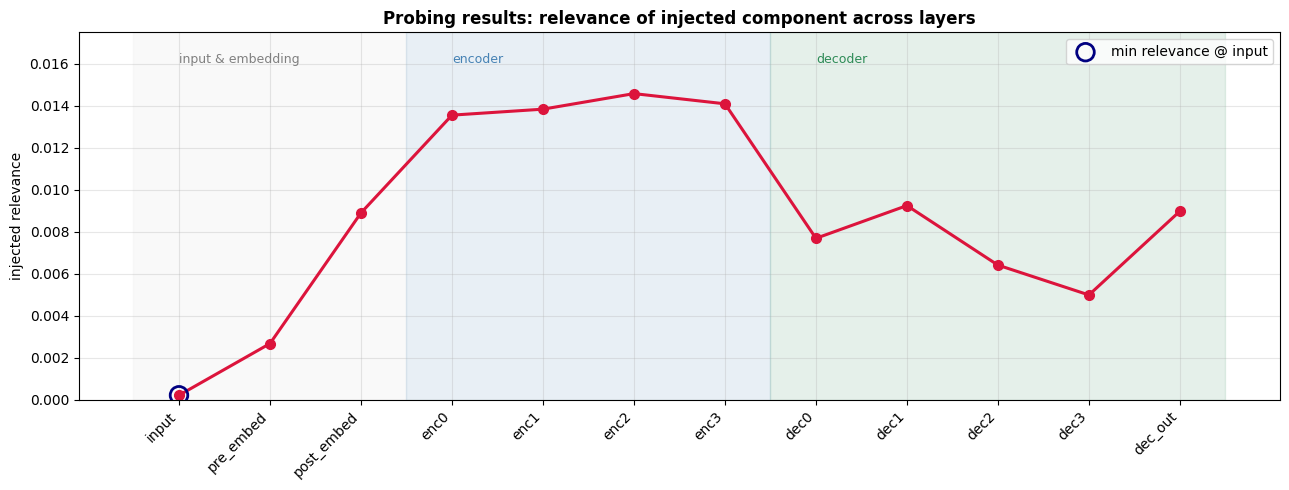

In [254]:
fig, ax = plt.subplots(figsize=(13, 5))

enc0 = REL_STAGES.index("enc0") if "enc0" in REL_STAGES else None
dec0 = REL_STAGES.index("dec0") if "dec0" in REL_STAGES else None

ax.axvspan(0-0.5, (enc0 if enc0 is not None else len(REL_STAGES))-0.5, color="lightgray", alpha=.12)
ax.text(0, max(rel)*1.1, "input & embedding", color="gray", fontsize=9)
if enc0 is not None:
    ax.axvspan(enc0-0.5, dec0-0.5, color="steelblue", alpha=.12)
    ax.text(enc0, max(rel)*1.1, "encoder", color="steelblue", fontsize=9)
if dec0 is not None:
    ax.axvspan(dec0-0.5, len(REL_STAGES)-0.5, color="seagreen", alpha=.12)
    ax.text(dec0, max(rel)*1.1, "decoder", color="seagreen", fontsize=9)

ax.plot(xs, rel, "o-", color="crimson", lw=2.2, ms=7)
ax.scatter([jmin], [rel[jmin]], s=160, facecolors="none", edgecolors="navy", lw=2,
           zorder=5, label=f"min relevance @ {REL_STAGES[jmin]}")

ax.set_xticks(xs)
ax.set_ylim(0, max(rel)*1.2)
ax.set_xticklabels(REL_STAGES, rotation=45, ha="right")
ax.set_ylabel("injected relevance") # on y we have a relevance score that measures how much the activations of the layer are affected by the presence of the injected component, compared to the background signal where the component is not present. 
ax.set_title("Probing results: relevance of injected component across layers", fontweight="bold")
ax.legend()
ax.grid(alpha=.3)
plt.tight_layout()
plt.savefig(OUT/"PLT1_relevance_detector.png", dpi=140, bbox_inches="tight")
plt.show()

### 3.2 - Recoverability of information (SLD-MDL)

**What it measures**: how *linearly and compressibly* the injected tone is encoded at each
stage, using the paper's prequential Minimum Description Length metric (Space Saving, SV).

A binary detection dataset is built: `bg + tone` (present, label 1) vs `bg` (absent,
label 0) over N random backgrounds with **random phase** as nuisance. A lightweight
linear probe is trained sequentially (prequential); the total codelength vs the uniform
binary baseline gives:

    SV  = 1 - L_probe / L_uniform         ← task: true labels
    SV_ctrl = 1 - L_probe / L_uniform     ← control: shuffled labels

Because the control has no real signal, `SV_ctrl ≤ 0`. The interpretable quantity is the gap:

    selectivity = SV - SV_ctrl

Large positive gap = the tone is genuinely and linearly accessible at that stage.
`SV_ctrl ≈ 0` confirms no spurious memorisation.

**Why leakage-free**: the target is binary detection (present/absent), *not* the frequency
itself. Phase randomisation prevents the probe from using phase as a shortcut. The control
calibrates against any residual overfitting.

**Key limitation**: measures strictly *linear* decodability. A stage can physically carry
the tone's information in a nonlinear form and still show low SV — the causal relevance
detector (Section 3) captures that orthogonal dimension.

In [255]:
N_PAIR = 30 # number of pairs of samples (original vs background) to generate for the MDL probing.
# Each pair consists of the activations of a layer for the original signal with the injected tone (label 1) and the activations of the same layer for the background signal without the tone (label 0).
# Total number of samples will be 2*N_PAIR, since we have N_PAIR samples for each class (original vs background).

Hf = {s: [] for s in REL_STAGES} 
# we initialize a dictionary Hf to store the activations of the layers for all the samples we will generate. 
# The keys of Hf are the names of the layers in REL_STAGES and the values are lists that will contain the activations of those layers for each sample.

We construct a binary dataset over many random backgrounds:
- class 0: background only (bg)
- class 1: background + injected tone (bg + tone)

Each tone instance uses random phase to remove alignment artifacts. All samples are forwarded through the model and hidden representations are extracted at each stage. For each stage, a linear classifier (logistic regression) is trained to distinguish presence vs absence of the tone.

Performance is evaluated using a prequential MDL criterion, where predictive probabilities are converted into code length:
L = -log2 p(y|x)

The recoverability score is defined as:
SV = 1 - L / L_uniform

In [256]:
yb = [] # we generate N_PAIR pairs of samples by creating a random background signal, injecting the tone into it, feeding both the original signal and the background signal to the model, and capturing the activations of the layers for both signals. 

for i in range(N_PAIR):
    # 1. we create a random background signal 
    background = sg.runRandomSignal(l_min=CONTEXT_LEN, l_max=CONTEXT_LEN, seed=SEED+i)

    # 2. we generate the injected tone 
    m = np.arange(len(background)) # m = time indices for the background signal, which will be used to generate the injected tone with the same length as the background signal.
    ph = rngm.uniform(0, 2*np.pi) # ph = random phase for the injected tone, which is sampled uniformly from the range [0, 2*pi) to ensure that the tone is not always in the same phase relative to the patches, which could bias the results.
    if spec["mode"] == "cpp":
        tn = amp_*np.sin(2*np.pi*float(spec["value"])*m/DEFAULT_PATCH_SIZE + ph)
    else:
        tn = amp_*np.sin(2*np.pi*float(spec["value"])*(m/float(json_config[0]["params"].get("fs",256))) + ph)
    
    # 3. we feed both the original signal (background + tone) and the background signal to the model and capture 
    # trace the background signal
    _, d0 = forward_capture(background)
    # trace the background signal with the tone injected
    _, d1 = forward_capture(background + tn)

    for s in REL_STAGES:
        Hf[s].append(np.ravel(d0[s])) # flaten
        Hf[s].append(np.ravel(d1[s])) # flatten
    yb += [0, 1] # we label the activations of the background signal without the tone injected as 0 and the activations of the original signal with the tone injected as 1, and we store these labels in the list yb, which will be used as the target variable for the MDL probing.

yb = np.array(yb) # we convert the list of labels yb to a numpy array for easier manipulation and to be compatible with the functions we will use later for the MDL probing.
Xb = {s: np.vstack(Hf[s]) for s in REL_STAGES} # we convert the lists of activations in Hf to numpy arrays and store them in a new dictionary Xb, where the keys are the same as in Hf and the values are numpy arrays of shape (num_samples, num_features) containing the activations of the layers for all the samples we generated.

In [257]:
yc = rngm.permutation(yb) 
# shuffle the labels to create a control condition where the relationship between the activations and the 
# labels is broken, which will allow us to assess the significance of the relevance scores we compute later 
# by comparing them to this control condition.

In [258]:
def mdl_codelength(X, y, K=5):
    """
    Computes the Minimum Description Length (MDL) codelength of a dataset (X, y) using K-fold cross-validation and a logistic regression classifier.
    The function first shuffles the dataset using a random seed, then splits it into K folds, and for each fold it trains a logistic regression classifier 
    on the training folds and evaluates it on the test fold. The codelength is computed as the sum of the negative log probabilities of the true
    classes predicted by the classifier on the test fold, clipped to avoid log of zero. The function returns the total codelength L.

    Why StandardScaler?
    - StandardScaler is used to standardize the features by removing the mean and scaling to unit variance, which can improve the performance of the logistic regression classifier and ensure that all features are on the same scale, which is important for the optimization process of logistic regression and can lead to better convergence and more accurate predictions.
    Why PCA?
    - PCA is used to reduce the dimensionality of the features to 50, which can help to improve the performance of the logistic regression classifier and to avoid overfitting, especially when the
    Why Logistic Regression?
    - Logistic regression is a simple and interpretable linear classifier that can capture the relationship between the
    Why lgbfs?
    - lbfgs is a quasi-Newton optimization algorithm that can be more efficient than other optimization algorithms for logistic regression, especially when the number of features is large, and it can also handle

    
    Args:
        X: a numpy array of shape (num_samples, num_features) containing the features of the dataset.
        y: a numpy array of shape (num_samples,) containing the labels of the dataset.
        K: the number of folds to use in the cross-validation (default is 5).
        seed: the random seed to use for shuffling the dataset (default is 0).
    Returns:
        L: the total codelength of the dataset (X, y) computed using K-fold cross-validation and a logistic regression classifier.  
    """
    r = np.random.default_rng(SEED)
    idx = r.permutation(len(y)) # shuffle the dataset using a random seed to ensure reproducibility and to avoid any bias in the order of the samples that could affect the results of the cross-validation.
    
    X = X[idx] # reorder the features and labels according to the shuffled indices to create a new dataset that is randomly permuted.
    y = y[idx] # reorder the features and labels according to the shuffled indices to create a new dataset that is randomly permuted.
    ch = np.array_split(np.arange(len(y)), K); L = len(ch[0])*1.0 # split into chunks

    for k in tqdm.tqdm(range(1, K), desc="Cross-validation"):
        train_idx = np.concatenate(ch[:k])
        test_idx = ch[k]
        model = make_pipeline(
            StandardScaler(), # PCA is used to reduce the dimensionality of the features to 50, which can help to improve the performance of the logistic regression classifier and to avoid overfitting, especially when the number of features is large compared to the number of samples.
            LogisticRegression(max_iter=2000, solver="lbfgs") 
        )
        model.fit(X[train_idx], y[train_idx]) # train a logistic regression classifier on the training folds (train_idx) using a pipeline that includes standard scaling of the features to improve the performance of the classifier and to ensure that the features are on the same scale, which is important for logistic regression.
        
        pred = model.predict_proba(X[test_idx])
        prediction = pred[np.arange(len(test_idx)), y[test_idx]]
        L += -np.log2(np.clip(prediction, 1e-6, 1)).sum() #  Negative Log-likelihood, in bits (log2)
    return L

In [259]:
# an SV measures how much a probe can compress the label information using the model’s representations.
SV  = {s: 1 - mdl_codelength(Xb[s], yb)/len(yb)*1.0 for s in REL_STAGES}
# SV is "Space Saving" and measures how much the activations of the layer can be compressed when using the true labels yb compared to a random permutation of the labels yc.
# We create a new dictionary SV where the keys are the same as in Xb and the values are the "Space Saving" scores computed as 1 minus the ratio of the MDL codelength of the dataset (Xb[s], yb) to the length of yb (Lu).


Cross-validation: 100%|██████████| 4/4 [00:00<00:00, 87.89it/s]


In [260]:
SV_ctrl = {s: 1 - mdl_codelength(Xb[s], yc)/len(yb)*1.0 for s in REL_STAGES}
# SV_ctrl is the "Space Saving" score computed using the shuffled labels yc, which serves as a control condition to assess the significance of the SV scores computed with the true labels yb.
# We create a new dictionary SV_ctrl where the keys are the same as in Xb and the values are the "Space Saving" scores computed as 1 minus the ratio of the MDL codelength of the dataset (Xb[s], yc) to the length of yb (Lu), where yc is a random permutation of yb that breaks the relationship between the activations and the labels, allowing us to assess the significance of the SV scores by comparing them to this control condition.

Cross-validation: 100%|██████████| 4/4 [00:00<00:00, 104.09it/s]


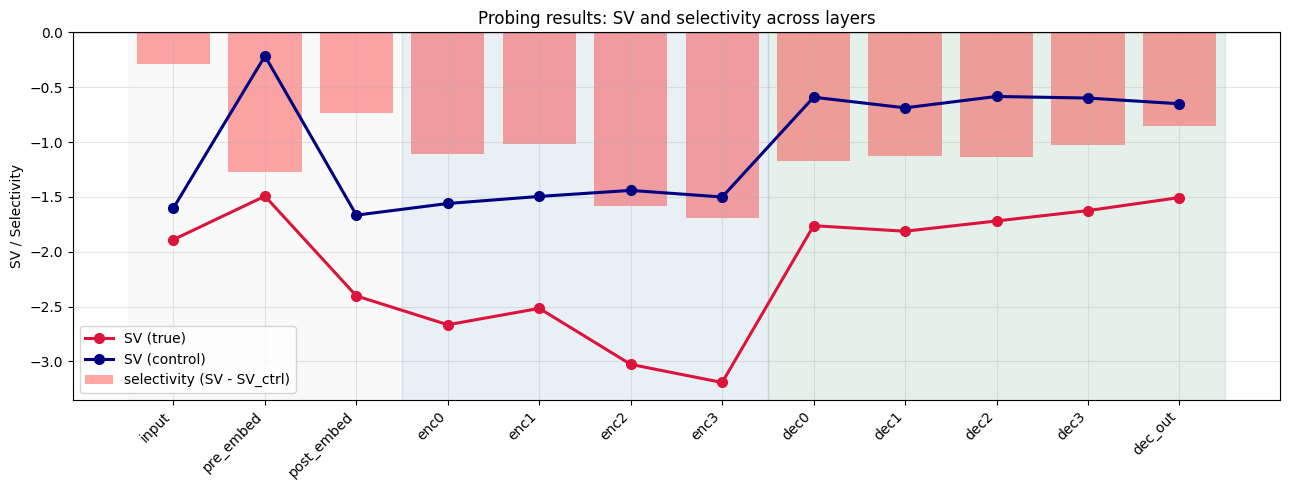

input      | selectivity=-0.2890 | NEG
pre_embed  | selectivity=-1.2773 | NEG
post_embed | selectivity=-0.7365 | NEG
enc0       | selectivity=-1.1052 | NEG
enc1       | selectivity=-1.0203 | NEG
enc2       | selectivity=-1.5858 | NEG
enc3       | selectivity=-1.6905 | NEG
dec0       | selectivity=-1.1710 | NEG
dec1       | selectivity=-1.1248 | NEG
dec2       | selectivity=-1.1348 | NEG
dec3       | selectivity=-1.0259 | NEG
dec_out    | selectivity=-0.8548 | NEG


In [261]:
xs = np.arange(len(REL_STAGES))
selectivity = np.array([SV[s] - SV_ctrl[s] for s in REL_STAGES])
sv_vals = np.array([SV[s] for s in REL_STAGES])
sv_ctrl_vals = np.array([SV_ctrl[s] for s in REL_STAGES])

fig, ax = plt.subplots(figsize=(13, 5))

enc0 = REL_STAGES.index("enc0") if "enc0" in REL_STAGES else None
dec0 = REL_STAGES.index("dec0") if "dec0" in REL_STAGES else None
ax.axvspan(-0.5, (enc0 if enc0 is not None else len(REL_STAGES))-0.5,
           color="lightgray", alpha=.12)

if enc0 is not None:
    ax.axvspan(enc0-0.5, dec0-0.5, color="steelblue", alpha=.12)
if dec0 is not None:
    ax.axvspan(dec0-0.5, len(REL_STAGES)-0.5, color="seagreen", alpha=.12)

# --- SV curves ---
ax.plot(xs, sv_vals, "o-", color="crimson", lw=2.2, ms=7, label="SV (true)")
ax.plot(xs, sv_ctrl_vals, "o-", color="navy", lw=2.2, ms=7, label="SV (control)")

colors = ["green" if v > 0 else "red" for v in selectivity]
ax.bar(xs, selectivity, color=colors, alpha=0.35, label="selectivity (SV - SV_ctrl)")
ax.axhline(0, color="black", lw=1, alpha=0.6)
ax.set_xticks(xs)
ax.set_xticklabels(REL_STAGES, rotation=45, ha="right")
ax.set_title("Probing results: SV and selectivity across layers")
ax.set_ylabel("SV / Selectivity")

ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT/"PLT2_SV_selectivity.png", dpi=140, bbox_inches="tight")
plt.show()

for s, v in zip(REL_STAGES, selectivity):
    sign = "POS" if v > 0 else ("ZERO" if abs(v) < 1e-6 else "NEG")
    print(f"{s:10s} | selectivity={v:.4f} | {sign}")

* SV high + selectivity positive
    → real encoded signal present
* SV high + selectivity ≈ 0
    → likely noise-fitting / no true structure
* SV low + control similar
    → no decodable information
* selectivity negative
    → pathological / overfit / instability in probe

## 4 - Round-trip: input vs forecast spectrum

In [262]:
def spec(x):
    x = np.asarray(x, float) - np.mean(x)
    m = np.abs(np.fft.rfft(x))
    return np.fft.rfftfreq(len(x)) * DEFAULT_PATCH_SIZE, m

In [263]:
forecast = pipeline.predict(torch.tensor(signal, dtype=torch.float32).unsqueeze(0))
pred = forecast[0].median(dim=0).values.numpy()
preds = [forecast[0][i].numpy() for i in range(9)]

cin, mi = spec(signal); 
cout, mo = spec(pred)

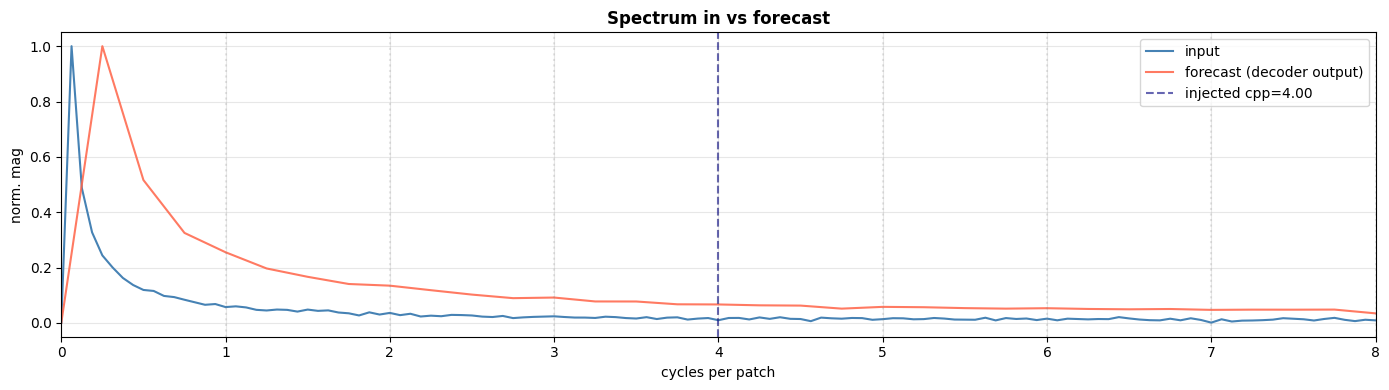

In [264]:
plt.figure(figsize=(14, 4))

plt.plot(cin, mi/(mi.max()+1e-9), color="steelblue", label="input")
plt.plot(cout, mo/(mo.max()+1e-9), color="tomato", alpha=.85, label="forecast (decoder output)")

plt.axvline(cpp, color="navy", ls="--", alpha=.6, label=f"injected cpp={cpp:.2f}")
for k in range(1, DEFAULT_PATCH_SIZE//2+1): 
    plt.axvline(k, color="grey", ls=":", alpha=.2)

plt.xlim(0, DEFAULT_PATCH_SIZE/2); plt.xlabel("cycles per patch")
plt.ylabel("norm. mag")
plt.title("Spectrum in vs forecast", fontweight="bold")
plt.legend()
plt.grid(alpha=.3)
plt.tight_layout()
plt.savefig(OUT/"PLT3.1_roundtrip.png", dpi=140, bbox_inches="tight")
plt.show()

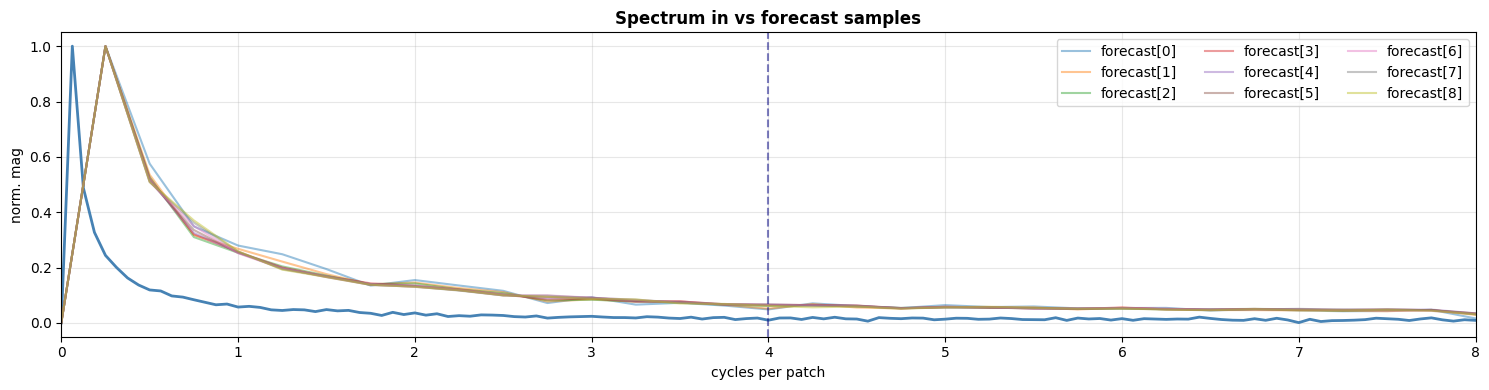

In [265]:
plt.figure(figsize=(15, 4))
plt.plot(cin, mi / (mi.max() + 1e-9), color="steelblue", lw=2)

for i, pred in enumerate(preds):
    cout, mo = spec(pred)
    plt.plot(cout, mo / (mo.max() + 1e-9), alpha=0.45, label=f"forecast[{i}]")

if cpp:
    plt.axvline(cpp, color="navy", ls="--", alpha=0.5)

plt.xlim(0, DEFAULT_PATCH_SIZE / 2)
plt.xlabel("cycles per patch")
plt.ylabel("norm. mag")
plt.title("Spectrum in vs forecast samples", fontweight="bold")
plt.legend(ncol=3)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT / "PLT3.2_roundtrip_samples.png", dpi=140, bbox_inches="tight")
plt.show()